# Supervised Generative PC on MNIST

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/supervised_generative_pc.ipynb)

This notebook demonstrates how to train a simple feedforward network with predictive coding to generate MNIST digits.

In [1]:
# %%capture
# !pip install torch==2.3.1
# !pip install torchvision==0.18.1
# !pip install matplotlib==3.0.0

In [11]:
import jpc

import jax
import jax.numpy as jnp
import equinox as eqx
import equinox.nn as nn
import optax
import matplotlib.colors as mcolors
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from scipy import linalg
import torch.nn.functional as F
import open_clip
from tqdm.notebook import tqdm

import warnings
warnings.simplefilter('ignore')  # ignore warnings

## Hyperparameters

We define some global parameters, including the network architecture, learning rate, batch size, etc.

In [3]:
SEED = 0

INPUT_DIM = 10
WIDTH = 300
DEPTH = 3
OUTPUT_DIM = 784
ACT_FN = "relu"

LEARNING_RATE = 1e-3
BATCH_SIZE = 64
MAX_T1 = 100
TEST_EVERY = 50
N_TRAIN_ITERS = 200

## Dataset

Some utils to fetch and plot MNIST.

In [4]:
def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=(0.1307), std=(0.3081)
                    )
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        img = torch.flatten(img)
        label = one_hot(label)
        return img, label


def one_hot(labels, n_classes=10):
    arr = torch.eye(n_classes)
    return arr[labels]


def plot_mnist_img_preds(imgs, labels, n_imgs=10):
    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imgs[i].reshape(28, 28), cmap=plt.cm.binary_r)
        plt.xlabel(jnp.argmax(labels, axis=1)[i], fontsize=16)
    plt.show()


## Network

For `jpc` to work, we need to provide a network with callable layers. This is easy to do with the PyTorch-like [`nn.Sequential()`](https://docs.kidger.site/equinox/api/nn/sequential/#equinox.nn.Sequential) in [equinox](https://github.com/patrick-kidger/equinox). For example, we can define a ReLU MLP with two hidden layers as follows

In [5]:
key = jax.random.PRNGKey(SEED)
key, *subkeys = jax.random.split(key, 4)
network = [
    nn.Sequential(
        [
            nn.Linear(10, 300, key=subkeys[0]),
            nn.Lambda(jax.nn.relu)
        ],
    ),
    nn.Sequential(
        [
            nn.Linear(300, 300, key=subkeys[1]),
            nn.Lambda(jax.nn.relu)
        ],
    ),
    nn.Linear(300, 784, key=subkeys[2]),
]

You can also use [`jpc.make_mlp()`](https://thebuckleylab.github.io/jpc/api/Utils/#jpc.make_mlp) to define a multi-layer perceptron (MLP) or fully connected network.

In [6]:
network = jpc.make_mlp(
    key,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    use_bias=True
)
print(network)

[Sequential(
  layers=(
    Lambda(fn=Identity()),
    Linear(
      weight=f32[300,10],
      bias=f32[300],
      in_features=10,
      out_features=300,
      use_bias=True
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x75f7f582f4c0>>),
    Linear(
      weight=f32[300,300],
      bias=f32[300],
      in_features=300,
      out_features=300,
      use_bias=True
    )
  )
), Sequential(
  layers=(
    Lambda(fn=<PjitFunction of <function relu at 0x75f7f582f4c0>>),
    Linear(
      weight=f32[784,300],
      bias=f32[784],
      in_features=300,
      out_features=784,
      use_bias=True
    )
  )
)]


## Train and test

A PC network can be updated in a single line of code with [`jpc.make_pc_step()`](https://thebuckleylab.github.io/jpc/api/Training/#jpc.make_pc_step). Similarly, we can use [`jpc.test_generative_pc()`](https://thebuckleylab.github.io/jpc/api/Testing/#jpc.test_generative_pc) to compute the network accuracy. Note that these functions are already "jitted" for optimised performance. Below we simply wrap each of these functions in training and test loops, respectively. 

Note that to train in an unsupervised way, you would simply need to remove the `input` from [`jpc.make_pc_step()`](https://thebuckleylab.github.io/jpc/api/Training/#jpc.make_pc_step) and the `evaluate()` script. See [this example notebook](https://thebuckleylab.github.io/jpc/examples/unsupervised_generative_pc/).

In [7]:
def evaluate(key, layer_sizes, batch_size, network, test_loader, max_t1):
    test_acc = 0
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        acc, img_preds = jpc.test_generative_pc(
            model=network,
            input=label_batch,
            output=img_batch,
            key=key,
            layer_sizes=layer_sizes,
            batch_size=batch_size,
            max_t1=max_t1
        )
        test_acc += acc

    avg_test_acc = test_acc / len(test_loader)

    return avg_test_acc, label_batch, img_preds


def train_with_energy(
    key,
    input_dim,
    width,
    depth,
    output_dim,
    batch_size,
    network,
    lr,
    max_t1,
    test_every,
    n_train_iters
):
    layer_sizes = [input_dim] + [width]*(depth-1) + [output_dim]
    optim = optax.adam(lr)
    opt_state = optim.init(
        (eqx.filter(network, eqx.is_array), None)
    )
    train_loader, test_loader = get_mnist_loaders(batch_size)

    train_energies, ts = [], []

    for iter, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        result = jpc.make_pc_step(
            model=network,
            optim=optim,
            opt_state=opt_state,
            input=label_batch,
            output=img_batch,
            max_t1=max_t1,
            record_activities=True,
            record_energies=True
        )
        network, opt_state = result["model"], result["opt_state"]
        train_loss = result["loss"]

        train_energies.append(result["energies"])
        ts.append(result["t_max"])


        if ((iter+1) % test_every) == 0:
            avg_test_acc, test_label_batch, img_preds = evaluate(
                key,
                layer_sizes,
                batch_size,
                network,
                test_loader,
                max_t1=max_t1
            )
            print(
                f"Train iter {iter+1}, train loss={train_loss:4f}, "
                f"avg test accuracy={avg_test_acc:4f}"
            )
            if (iter+1) >= n_train_iters:
                break

    plot_mnist_img_preds(img_preds, test_label_batch)
    return result["model"], train_energies, ts


def plot_train_energies(energies, ts):
    t_max = int(ts[0])
    norm = mcolors.Normalize(vmin=0, vmax=len(energies)-1)
    fig, ax = plt.subplots(figsize=(8, 4))
    
    cmap_blues = plt.get_cmap("Blues")
    cmap_reds = plt.get_cmap("Reds")
    cmap_greens = plt.get_cmap("Greens")
    
    legend_handles = []
    legend_labels = []
    
    for t, energies_iter in enumerate(energies):
        line1, = ax.plot(energies_iter[0, :t_max], color=cmap_blues(norm(t)))
        line2, = ax.plot(energies_iter[1, :t_max], color=cmap_reds(norm(t)))
        line3, = ax.plot(energies_iter[2, :t_max], color=cmap_greens(norm(t)))
    
        if t == 70:
            legend_handles.append(line1)
            legend_labels.append("$\ell_1$")
            legend_handles.append(line2)
            legend_labels.append("$\ell_2$")
            legend_handles.append(line3)
            legend_labels.append("$\ell_3$")
    
    ax.legend(legend_handles, legend_labels, loc="best", fontsize=16)
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap("Greys"), norm=norm)
    sm._A = []
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Training iteration", fontsize=16, labelpad=14)
    cbar.ax.tick_params(labelsize=14) 
    plt.gca().tick_params(axis="both", which="major", labelsize=16)
    
    ax.set_xlabel("Inference iterations", fontsize=18, labelpad=14)
    ax.set_ylabel("Energy", fontsize=18, labelpad=14)
    ax.set_yscale("log")
    plt.show()

In [8]:
def compute_clipscore(images, labels, model=None, preprocess=None, batch_size=32):
    """
    Compute CLIPScore for evaluating image-text alignment.
    
    Args:
        images: torch.Tensor of images (N, C, H, W) or list of PIL Images
        captions: list of text captions (strings) corresponding to images
        model: CLIP model (if None, loads ViT-B/32)
        preprocess: CLIP preprocessing function
        batch_size: Batch size for processing
    
    Returns:
        pd.DataFrame with CLIPScore statistics
    """
    if model is None or preprocess is None:
        model, _, preprocess = open_clip.create_model_and_transforms('ViT-L-14-quickgelu', pretrained='openai')

        model.to('cuda')
        model.eval()
    
    tokenizer = open_clip.get_tokenizer('ViT-L-14')
    
    # Process images
    if isinstance(images, torch.Tensor):
        # Convert tensor to list of PIL images if needed
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)  # Convert to (N, 3, H, W)
        images = [Image.fromarray((img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)) 
                for img in images]
    
    scores = []
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        
        # Preprocess
        img_inputs = torch.stack([preprocess(img) for img in batch_imgs]).to('cuda')
        text_inputs = tokenizer(batch_labels).to('cuda')
        
        with torch.no_grad():
            img_features = model.encode_image(img_inputs)
            text_features = model.encode_text(text_inputs)
            
            # Normalize features
            img_features = img_features / img_features.norm(dim=-1, keepdim=True)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
            
            # Compute cosine similarity
            similarity = (img_features * text_features).sum(dim=-1)
        
        scores.extend(similarity.cpu().numpy())
    
    scores = np.array(scores)
    
    return pd.DataFrame({
        'metric': ['CLIPScore'],
        'mean': [scores.mean()],
        'std': [scores.std()],
        'min': [scores.min()],
        'max': [scores.max()]
    })



def compute_fcd(real_images, fake_images, model=None, preprocess=None, batch_size=32):
    """
    Compute Fréchet CLIP Distance between real and generated images.
    
    Args:
        real_images: torch.Tensor of real images (N, C, H, W) or list of PIL Images
        fake_images: torch.Tensor of generated images (N, C, H, W) or list of PIL Images
        model: CLIP model (if None, loads ViT-L-14-quickgelu)
        preprocess: CLIP preprocessing function
        batch_size: Batch size for processing
    
    Returns:
        pd.DataFrame with FCD score
    """
    if model is None or preprocess is None:
        model, _, preprocess = open_clip.create_model_and_transforms(
            'ViT-L-14-quickgelu', pretrained='openai'
        )
        model.to('cuda')
        model.eval()
    
    def get_clip_features(images):
        # Convert tensors to PIL images if needed
        if isinstance(images, torch.Tensor):
            if images.shape[1] == 1:  # If grayscale (N, 1, H, W)
                images = images.repeat(1, 3, 1, 1)  # Convert to (N, 3, H, W)
            images = [Image.fromarray((img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)) 
                      for img in images]
        
        features = []
        for i in range(0, len(images), batch_size):
            batch_imgs = images[i:i+batch_size]
            img_inputs = torch.stack([preprocess(img) for img in batch_imgs]).to('cuda')
            
            with torch.no_grad():
                feat = model.encode_image(img_inputs)
                feat = feat / feat.norm(dim=-1, keepdim=True)  # Normalize
            features.append(feat.cpu().numpy())
        return np.concatenate(features, axis=0)
    
    real_features = get_clip_features(real_images)
    fake_features = get_clip_features(fake_images)
    
    # Calculate mean and covariance
    mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)
    
    # Compute FCD
    diff = mu_real - mu_fake
    covmean, _ = linalg.sqrtm(sigma_real.dot(sigma_fake), disp=False)
    
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fcd = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    
    return pd.DataFrame({
        'metric': ['Fréchet CLIP Distance'],
        'mean': [fcd.mean()],
        'std': [fcd.std()],
        'min': [fcd.min()],
        'max': [fcd.max()]
    })


def get_real_and_fake_images_pc(key, layer_sizes, batch_size, network, test_loader):
    
    img_batch, label_batch = next(iter(test_loader))
    img_batch, label_batch = jnp.asarray(img_batch.numpy()), jnp.asarray(label_batch.numpy())

    acc, img_preds = jpc.test_generative_pc(
        model=network,
        input=label_batch,
        output=img_batch,
        key=key,
        layer_sizes=layer_sizes,
        batch_size=batch_size,
        max_t1=1000
    )

    digit_vocab = {
        0: "zero",
        1: "one",
        2: "two",
        3: "three",
        4: "four",
        5: "five",
        6: "six",
        7: "seven",
        8: "eight",
        9: "nine"
    }
    real_images = torch.tensor(np.asarray(img_batch)).reshape(-1, 1, 28, 28)
    fake_images = torch.tensor(np.asarray(img_preds)).reshape(-1, 1, 28, 28)
    label_batch = torch.tensor(np.asarray(label_batch))
    str_labels = ['a photo of a grayscale number ' + digit_vocab[int(jnp.argmax(label))] for label in label_batch.numpy()]
    return real_images, fake_images, str_labels



In [ ]:
def evaluate(key, layer_sizes, batch_size, network, test_loader, max_t1):
    test_acc = 0
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        acc, img_preds = jpc.test_generative_pc(
            model=network,
            input=label_batch,
            output=img_batch,
            key=key,
            layer_sizes=layer_sizes,
            batch_size=batch_size,
            max_t1=max_t1
        )
        test_acc += acc

    avg_test_acc = test_acc / len(test_loader)

    return avg_test_acc, label_batch, img_preds


def train(
    key,
    input_dim,
    width,
    depth,
    output_dim,
    batch_size,
    network,
    lr,
    max_t1,
    test_every,
    n_train_iters
):
    layer_sizes = [input_dim] + [width]*(depth-1) + [output_dim]
    optim = optax.adam(lr)
    opt_state = optim.init(
        (eqx.filter(network, eqx.is_array), None)
    )
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for iter, (img_batch, label_batch) in tqdm(enumerate(train_loader), total = min(n_train_iters, len(train_loader))):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        result = jpc.make_pc_step(
            model=network,
            optim=optim,
            opt_state=opt_state,
            input=label_batch,
            output=img_batch,
            max_t1=max_t1
        )
        network, opt_state = result["model"], result["opt_state"]
        train_loss = result["loss"]
    #     if ((iter+1) % test_every) == 0:
    #         avg_test_acc, test_label_batch, img_preds = evaluate(
    #             key,
    #             layer_sizes,
    #             batch_size,
    #             network,
    #             test_loader,
    #             max_t1=max_t1
    #         )
    #         print(
    #             f"Train iter {iter+1}, train loss={train_loss:4f}, "
    #             f"avg test accuracy={avg_test_acc:4f}"
    #         )
    #         if (iter+1) >= n_train_iters:
    #             break

    # plot_mnist_img_preds(img_preds, test_label_batch)

    real_images, fake_images, str_labels = get_real_and_fake_images_pc(
        key, layer_sizes, batch_size, network, test_loader
    )


    clip_results = compute_clipscore(fake_images, str_labels, batch_size=BATCH_SIZE)
    fcd_results = compute_fcd(real_images, fake_images, batch_size=BATCH_SIZE)

    # Combine all metrics into a single report
    print("Combined Evaluation Report:")
    combined_df = pd.concat([clip_results, fcd_results], ignore_index=True)
    print(combined_df)
    return network


## Run

  0%|          | 0/200 [00:00<?, ?it/s]

Train iter 50, train loss=0.311193, avg test accuracy=79.857773
Train iter 100, train loss=0.303820, avg test accuracy=83.453529
Train iter 150, train loss=0.307729, avg test accuracy=84.254807
Train iter 200, train loss=0.281698, avg test accuracy=84.354973


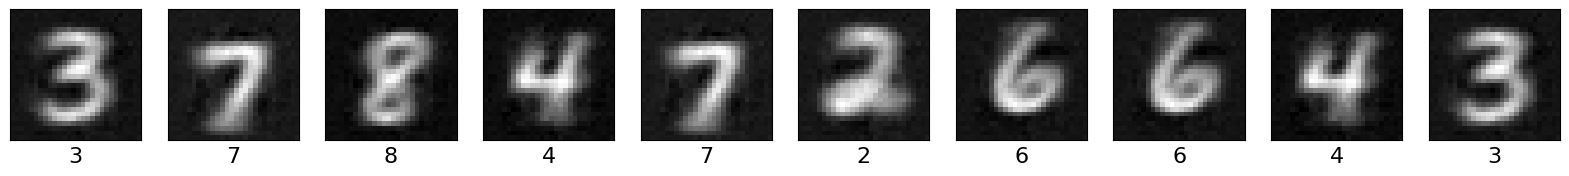

Combined Evaluation Report:
                  metric      mean       std       min       max
0              CLIPScore  0.200433  0.009489  0.188047  0.215659
1  Fréchet CLIP Distance  0.296030  0.000000  0.296030  0.296030


In [13]:
network = train(
    key=key,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    batch_size=BATCH_SIZE,
    network=network,
    lr=LEARNING_RATE,
    max_t1=MAX_T1,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

2025-11-14 16:50:54.084357: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 11.95GiB (12828009413 bytes) by rematerialization; only reduced to 16.22GiB (17420315238 bytes), down from 16.22GiB (17420315238 bytes) originally


Train iter 50, train loss=0.273291, avg test accuracy=65.434700
Train iter 100, train loss=0.316732, avg test accuracy=62.790466
Train iter 150, train loss=0.303811, avg test accuracy=59.144630
Train iter 200, train loss=0.273248, avg test accuracy=56.099762


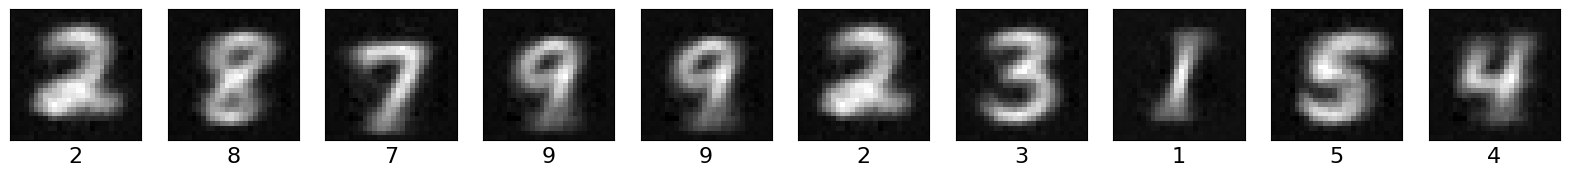

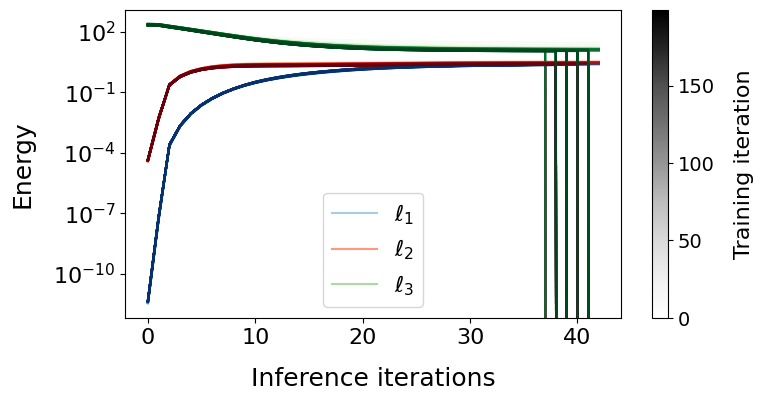

In [ ]:
network, energies, ts = train_with_energy(
    key=key,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    batch_size=BATCH_SIZE,
    network=network,
    lr=LEARNING_RATE,
    max_t1=MAX_T1,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS
)

plot_train_energies(energies, ts)

In [34]:
energies[0][0]

Array([3.8062374e-12, 5.5147424e-08, 2.4462584e-04, 2.2711640e-03,
       9.1707502e-03, 2.4883203e-02, 5.3500928e-02, 9.8504215e-02,
       1.6217485e-01, 2.4402821e-01, 3.4324908e-01, 4.5637348e-01,
       5.7811642e-01, 7.0699674e-01, 8.4050441e-01, 9.7711205e-01,
       1.1075761e+00, 1.2335711e+00, 1.3542523e+00, 1.4699736e+00,
       1.5775063e+00, 1.6794078e+00, 1.7761600e+00, 1.8654029e+00,
       1.9520056e+00, 2.0319495e+00, 2.1038656e+00, 2.1712346e+00,
       2.2332296e+00, 2.2899008e+00, 2.3419027e+00, 2.3917840e+00,
       2.4367070e+00, 2.4794607e+00, 2.5189738e+00, 2.5561812e+00,
       2.5907736e+00, 2.6231108e+00, 2.6531646e+00, 2.6813788e+00,
       2.7083502e+00, 2.7333951e+00, 2.7570419e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e